# Tufa Labs ARC3 submission

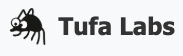

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["ahmedmobasher86/arcagi3-agent", "jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if TRUE_SUBMISSION:  # serving Qwen needs the eval GPU; the CPU-safe commit skips it
    for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# In-memory harness patches. Inlined from submission/_duck_patched/duck_patches.py
# by build_duck_patched.py — edit that file and rebuild, never edit this cell.
#
# The Kaggle source dataset is read-only, so these are monkey-patches. They run
# after the bundle is on sys.path and the benchmark is loaded, before bm.run().
# Model, sampling, concurrency, budgets and the game list are untouched.
# ============================================================================

"""In-memory patches applied to the read-only TAAF duck bundle before `bm.run()`.

The Kaggle dataset that carries the duck harness is read-only, so every fix here is a
monkey-patch installed at import time in the notebook. Each patch is independently
guarded: if the upstream shape it expects is missing, that patch reports FAIL and the
others still apply. Nothing here changes the model, sampling, concurrency or budgets.

PATCH 1 — ACTION7 round trip (BUG FIX).
    `inference.agent.action_names.ENGINE_TO_MODEL_ACTION` maps ACTION1..6 + RESET only.
    `to_model_action("ACTION7")` passes the name through to the model, but
    `to_engine_action("ACTION7")` returns None, so solver.py's action parser rejects it
    with "Unknown action at index N". The model is offered a legal action it can never
    execute. 6 of the 25 public games use ACTION7 (ar25, bp35, lf52, sb26, sk48, su15).

PATCH 2 — animation metadata.
    `taaf.game.GameState.animation_frames` already exposes the intermediate frames of a
    multi-frame action, but only the final frame ever reaches the model. This adds a few
    scalar fields per action describing what moved during the animation. No images, no
    raw frames — roughly 20-40 tokens per action of causal signal.

NOT PATCHED — RESET restriction.
    The public fork this work draws on restricts RESET to GAME_OVER. Our bundle already
    does the equivalent, more thoroughly: `solver._engine_action_names` strips RESET from
    the model's choices unconditionally (solver.py:116-117) and `_execute_auto_reset()`
    fires on GAME_OVER (solver.py:278-282). No change needed; verified by
    `verify_reset_already_handled()` below.
"""
from __future__ import annotations

from typing import Any

# Engine action ids that count as real actions (RESET is id 0 and is scored differently).
_ACTION7 = "ACTION7"


def patch_action7() -> str:
    """Make ACTION7 survive the model<->engine name round trip. Returns a status line."""
    from inference.agent import action_names as an

    if _ACTION7 in an.ENGINE_TO_MODEL_ACTION:
        return "patch1 action7: SKIP (already mapped)"

    # ACTION7's meaning is not fixed across games, so it has no friendly label like
    # UP/DOWN/MOUSE. Map it to itself: the model sees "ACTION7" and the engine gets
    # "ACTION7" back.
    an.ENGINE_TO_MODEL_ACTION[_ACTION7] = _ACTION7
    an.MODEL_TO_ENGINE_ACTION.clear()
    an.MODEL_TO_ENGINE_ACTION.update(
        {value: key for key, value in an.ENGINE_TO_MODEL_ACTION.items()}
    )

    if an.to_engine_action(an.to_model_action(_ACTION7)) != _ACTION7:
        raise RuntimeError("patch1 action7: round trip still broken after patch")
    return "patch1 action7: OK"


def patch_animation_producer() -> str:
    """Attach the animation summary to the payload `_execute_action` returns.

    `_compact_action_result` (patch 2b) only forwards these keys; this is what creates
    them. Wrapping the method rather than reimplementing it keeps us insulated from
    upstream changes to the payload's other fields.
    """
    from inference.framework import solver

    session = getattr(solver, "_HarnessGameSession", None)
    if session is None or not hasattr(session, "_execute_action"):
        return "patch2a animation-producer: FAIL (_HarnessGameSession._execute_action not found)"
    if getattr(session._execute_action, "_animation_patched", False):
        return "patch2a animation-producer: SKIP (already applied)"

    original = session._execute_action

    def _execute_action(self: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        payload = original(self, *args, **kwargs)
        if isinstance(payload, dict):
            try:
                payload.update(summarize_animation(self.game.current_state))
            except Exception:
                pass  # never let telemetry break an action
        return payload

    _execute_action._animation_patched = True  # type: ignore[attr-defined]
    session._execute_action = _execute_action
    return "patch2a animation-producer: OK"


def patch_animation_metadata() -> str:
    """Forward the animation summary through the compaction the model actually sees."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_compact_action_result"):
        return "patch2b animation-forward: FAIL (ToolAgent._compact_action_result not found)"
    if getattr(agent_cls._compact_action_result, "_animation_patched", False):
        return "patch2b animation-forward: SKIP (already applied)"

    original = agent_cls._compact_action_result

    def _compact_action_result(self: Any, payload: dict[str, Any]) -> dict[str, Any]:
        compact = original(self, payload)
        for key in _ANIMATION_KEYS:
            if key in payload:
                compact[key] = payload[key]
        return compact

    _compact_action_result._animation_patched = True  # type: ignore[attr-defined]
    agent_cls._compact_action_result = _compact_action_result
    return "patch2b animation-forward: OK"


_ANIMATION_KEYS = (
    "animation_frame_count",
    "animation_changed",
    "animation_only_changed",
    "animation_changed_cell_count",
    "animation_changed_bbox",
)


def summarize_animation(state: Any) -> dict[str, Any]:
    """Describe the animation of a just-executed action as a handful of scalars.

    `state` is a taaf GameState. Returns {} when the action produced no animation, so
    single-frame actions cost zero extra tokens.
    """
    try:
        animation = list(state.animation_frames)
    except Exception:
        return {}
    if not animation:
        return {}

    final = _frame_rows(state.frame)
    changed_cells: list[tuple[int, int]] = []
    only_in_animation = False

    for frame in animation:
        rows = _frame_rows(frame)
        for y, (arow, frow) in enumerate(zip(rows, final)):
            for x, (avalue, fvalue) in enumerate(zip(arow, frow)):
                if avalue != fvalue:
                    changed_cells.append((x, y))
                    only_in_animation = True

    out: dict[str, Any] = {
        "animation_frame_count": len(animation),
        "animation_changed": bool(changed_cells),
        # True when the animation showed motion that is NOT visible in the final frame —
        # i.e. something moved and returned, or moved through. This is the signal the
        # model cannot otherwise recover.
        "animation_only_changed": only_in_animation,
        "animation_changed_cell_count": len(set(changed_cells)),
    }
    if changed_cells:
        xs = [x for x, _ in changed_cells]
        ys = [y for _, y in changed_cells]
        out["animation_changed_bbox"] = [min(xs), min(ys), max(xs), max(ys)]
    return out


def _frame_rows(frame: Any) -> list[list[int]]:
    data = getattr(frame, "data", frame)
    return [list(row) for row in data]


def verify_reset_already_handled() -> str:
    """Confirm our bundle already restricts RESET, so patch 3 is genuinely unnecessary."""
    import inspect

    from inference.framework import solver

    src = inspect.getsource(solver._engine_action_names)
    strips_reset = 'if name == "RESET"' in src and "continue" in src
    auto_resets = hasattr(solver._HarnessGameSession, "_execute_auto_reset")
    if strips_reset and auto_resets:
        return "patch3 reset: NOT NEEDED (RESET stripped from choices + auto-reset on GAME_OVER)"
    return (
        f"patch3 reset: REVIEW (strips_reset={strips_reset}, auto_resets={auto_resets}) "
        "— upstream changed, re-check whether RESET must be restricted"
    )


def patch_dynamic_grid_burner() -> str:
    """Burn coordinate grids into the images sent to the VLM (Spatial Overlay)."""
    from inference.agent import vision_context

    if getattr(vision_context.frame_to_png_data_url, "_grid_burner_patched", False):
        return "patch4 grid-burner: SKIP (already applied)"

    original_func = vision_context.frame_to_png_data_url

    def frame_to_png_data_url_patched(frame: Any, *, upscale: int | None = None) -> str:
        import io, base64
        from PIL import Image, ImageDraw

        rows = len(frame.grid)
        cols = max((len(row) for row in frame.grid), default=0)
        if rows <= 0 or cols <= 0:
            raise ValueError("Cannot render an empty grid as an image.")

        scale = vision_context.current_grid_image_upscale() if upscale is None else max(1, int(upscale))
        image = Image.new("RGB", (cols, rows), vision_context.ARC_COLOR_MAP[0])
        pixels = image.load()
        for row_idx, row in enumerate(frame.grid):
            for col_idx in range(cols):
                value = row[col_idx] if col_idx < len(row) else 0
                pixels[col_idx, row_idx] = vision_context.ARC_COLOR_MAP.get(int(value), vision_context.ARC_COLOR_MAP[0])
        
        if scale > 1:
            image = image.resize((cols * scale, rows * scale), Image.Resampling.NEAREST)
            draw = ImageDraw.Draw(image)
            
            # Draw subtle grid lines
            grid_color = (128, 128, 128)
            for r in range(rows + 1):
                y = r * scale
                width = 2 if r % 5 == 0 else 1
                draw.line([(0, y), (cols * scale, y)], fill=grid_color, width=width)
            for c in range(cols + 1):
                x = c * scale
                width = 2 if c % 5 == 0 else 1
                draw.line([(x, 0), (x, rows * scale)], fill=grid_color, width=width)

            # Draw coordinate labels
            try:
                from PIL import ImageFont
                font = ImageFont.load_default()
                text_color = (200, 200, 200)
                # row labels (left edge)
                for r in range(rows):
                    if r % 5 == 0:
                        draw.text((2, r * scale + 2), str(r), fill=text_color, font=font)
                # col labels (top edge)
                for c in range(cols):
                    if c % 5 == 0 and c > 0:
                        draw.text((c * scale + 2, 2), str(c), fill=text_color, font=font)
            except Exception:
                pass

        buffer = io.BytesIO()
        image.save(buffer, format="PNG")
        encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
        return f"data:image/png;base64,{encoded}"

    frame_to_png_data_url_patched._grid_burner_patched = True  # type: ignore[attr-defined]
    vision_context.frame_to_png_data_url = frame_to_png_data_url_patched
    return "patch4 grid-burner: OK"


def patch_prompts() -> str:
    """Update system prompt to instruct the model to use the grid coordinates."""
    from inference.agent import prompts
    if "numeric coordinate labels" in prompts.MULTIMODAL_CONTEXT_ADDENDUM:
        return "patch5 prompts: SKIP (already applied)"
    prompts.MULTIMODAL_CONTEXT_ADDENDUM += "- The image contains numeric coordinate labels (0, 5, 10...) along the top and left edges. Use these to precisely identify row and column indices for spatial reasoning and action targeting.\n"
    return "patch5 prompts: OK"


def patch_tool_agent_analyze() -> str:
    """Intercept the Qwen-27B action generation pipeline to inject TransferExplorer and Retrospective summaries."""
    import sys
    from pathlib import Path
    
    # Ensure arcagi3 is in sys.path
    possible_paths = [
        Path("/kaggle/input/arcagi3-agent/lib"),
        Path("/kaggle/input/datasets/ahmedmobasher86/arcagi3-agent/lib"),
        Path(__file__).resolve().parents[2] / "src", # Local fallback for dev
    ]
    for p in possible_paths:
        if p.exists() and str(p) not in sys.path:
            sys.path.insert(0, str(p))
            
    from inference.agent import tool_agent
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "analyze"):
        return "patch6 tool_agent_analyze: FAIL (ToolAgent.analyze not found)"
    if getattr(agent_cls.analyze, "_tool_agent_patched", False):
        return "patch6 tool_agent_analyze: SKIP (already applied)"

    original_analyze = agent_cls.analyze

    def analyze_patched(
        self,
        state_path: Path,
        action_num: int,
        valid_actions: list[str] | None = None,
        step_env = None,
        *args,
        **kwargs
    ):
        from inference.agent.runtime_state import load_runtime_state
        from inference.agent.tool_agent import AnalyzerTurnResult
        import arcengine
        
        # Phase 3: Inject Retrospective Summaries into system prompt
        original_system_prompt = getattr(self, "_original_system_prompt", None)
        if original_system_prompt is None:
            self._original_system_prompt = self._system_prompt
            original_system_prompt = self._system_prompt
            
        retrospectives = getattr(self, "_retrospective_summaries", [])
        if retrospectives:
            retro_text = "\n\nRetrospective Summaries from previous levels of this game:\n" + "\n".join(f"- {r}" for r in retrospectives)
            self._system_prompt = original_system_prompt + retro_text
        else:
            self._system_prompt = original_system_prompt

        # Phase 2: Heuristic Prober (TransferExplorer)
        if action_num < 200 and step_env is not None:
            try:
                from arcagi3.transfer_explorer import TransferExplorer
                if not hasattr(self, "_transfer_explorer_instance"):
                    self._transfer_explorer_instance = TransferExplorer()
                
                current_frame, _ = load_runtime_state(state_path)
                grid = current_frame.grid
                
                gstate_terminal = False
                gstate_notplayed = (action_num == 0)
                levels = current_frame.level
                
                # Format available actions as integers for TransferExplorer
                available_ids = []
                for name in (valid_actions or []):
                    try:
                        available_ids.append(arcengine.GameAction.from_name(name).value)
                    except Exception:
                        pass
                
                # numpy is required by arcagi3
                import numpy as np
                grid_np = np.array(grid, dtype=np.int32)
                
                action = self._transfer_explorer_instance.decide(
                    grid_np, gstate_terminal, gstate_notplayed, levels, available_ids
                )
                
                step_args = None
                if action and action[0] == "S":
                    action_name = arcengine.GameAction.from_id(action[1]).name
                    step_args = {"action": action_name}
                elif action and action[0] == "C":
                    step_args = {"action": "ACTION6", "col": action[1], "row": action[2]}
                elif action and action[0] == "reset":
                    step_args = {"action": "RESET"}
                    
                if step_args is not None:
                    # execute the symbolic transition
                    result = step_env(step_args)
                    # Note: we should still check if this action completed the level!
                    if self._last_action_result and self._last_action_result.get("level_completed"):
                        # Mark that we should do retrospective, but wait, the prober doesn't use the LLM, 
                        # so there are no LLM history messages for this level! We can just skip retro for heuristic clears.
                        pass
                    return AnalyzerTurnResult(
                        step_executed=True,
                        reasoning=f"TransferExplorer heuristic probe executed: {step_args}",
                        yielded_control=False,
                    )
            except Exception as exc:
                import logging
                logging.getLogger(__name__).warning("TransferExplorer failed, falling back to LLM: %s", exc)
                pass
                
        # Fallback to normal Qwen LLM analysis
        result = original_analyze(self, state_path, action_num, valid_actions, step_env, *args, **kwargs)
        
        # Phase 3: Retrospective generation on level complete
        if hasattr(self, "_last_action_result") and self._last_action_result and self._last_action_result.get("level_completed"):
            try:
                retro_messages = list(self._history_messages)
                retro_messages.append({
                    "role": "user", 
                    "content": "The level was just solved! Briefly summarize the core mechanic of this level and the strategy used to solve it. This summary will be provided to you in future levels of this game, so focus on transferable rules (e.g. 'green objects always move right until they hit a wall'). Keep it under 4 sentences."
                })
                # Call chat completion
                retro_result = self._chat_completion(retro_messages, tools=None)
                retro_content = retro_result.message.get("content", "")
                if retro_content:
                    if not hasattr(self, "_retrospective_summaries"):
                        self._retrospective_summaries = []
                    self._retrospective_summaries.append(retro_content)
            except Exception as exc:
                import logging
                logging.getLogger(__name__).warning("Retrospective generation failed: %s", exc)
                pass
                
        return result

    analyze_patched._tool_agent_patched = True  # type: ignore[attr-defined]
    agent_cls.analyze = analyze_patched
    return "patch6 tool_agent_analyze: OK"


# --- PATCH 7: run watchdog -------------------------------------------------------
#
# Detects stalled games in the harness loop and stops them so one wedged game
# cannot silently eat the submission's wall-clock budget (the host reported ~1/3
# of failed submissions "stuck silently"). Three mechanisms, all cooperative:
#
#   1. STALL DETECTION — progress is (scored action count, levels completed). If
#      neither moves for TAAF_WATCHDOG_STALL_S seconds (default 900) the game is
#      stalled: the analyzer is wedged in a retry/parse loop, the endpoint died,
#      or the model deliberates forever without acting.
#   2. RESET-AND-CONTINUE — the first TAAF_WATCHDOG_MAX_RESETS stalls (default 1)
#      are answered with one engine RESET (level reset under ONLY_RESET_LEVELS;
#      costs 1 scored action) and a fresh timer, which un-wedges games stuck in a
#      degenerate board state. The RESET is only issued from the session's own
#      worker thread — `should_stop` is also polled by analyzer-side threads, and
#      those must never touch the engine.
#   3. KILL + WALL CAP — further stalls stop the game cleanly (`should_stop`
#      returns True, the play loop exits, `finish_game` banks whatever levels are
#      already completed — nothing earned is lost). Independently, a per-game
#      wall-clock cap (TAAF_WATCHDOG_WALL_CAP_S, default 7200; 0 disables) stops
#      any game the solver did not already bound via `max_runtime_s_per_game`.
#
# TAAF_WATCHDOG=0 disables the whole patch at call time.


def _watchdog_env_float(name: str, default: float) -> float:
    import os

    try:
        return float(os.environ.get(name, "") or default)
    except (TypeError, ValueError):
        return default


def _watchdog_enabled() -> bool:
    import os

    return os.environ.get("TAAF_WATCHDOG", "1").strip() not in {"0", "false", "False"}


def _watchdog_state(session: Any) -> dict[str, Any]:
    import time

    wd = getattr(session, "_watchdog_state", None)
    if wd is None:
        wd = {
            "stall_s": max(1.0, _watchdog_env_float("TAAF_WATCHDOG_STALL_S", 900.0)),
            "wall_cap_s": _watchdog_env_float("TAAF_WATCHDOG_WALL_CAP_S", 7200.0),
            "max_resets": int(_watchdog_env_float("TAAF_WATCHDOG_MAX_RESETS", 1.0)),
            "progress": None,
            "t_progress": time.monotonic(),
            "resets_done": 0,
            "in_reset": False,
            "killed": None,  # None | "stall" | "wall_cap"
            "thread_id": None,
        }
        session._watchdog_state = wd
    return wd


def patch_watchdog() -> str:
    """Install the stall watchdog on the harness game session."""
    import threading
    import time

    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "should_stop"):
        return "patch7 watchdog: FAIL (_HarnessGameSession.should_stop not found)"
    if getattr(session_cls.should_stop, "_watchdog_patched", False):
        return "patch7 watchdog: SKIP (already applied)"

    original_should_stop = session_cls.should_stop
    original_play = session_cls.play

    def _log(session: Any, message: str) -> None:
        run = getattr(session.game, "game_run", None)
        game_id = getattr(run, "game_id", "?") if run is not None else "?"
        print(f"[watchdog] {game_id}: {message}", flush=True)

    def play(self: Any) -> None:
        wd = _watchdog_state(self)
        wd["thread_id"] = threading.get_ident()
        wd["t_progress"] = time.monotonic()
        return original_play(self)

    def should_stop(self: Any) -> bool:
        if original_should_stop(self):
            return True
        if not _watchdog_enabled():
            return False
        try:
            wd = _watchdog_state(self)
            now = time.monotonic()

            run = self.game.game_run
            levels = int(run.levels_completed) if run is not None else 0
            progress = (self.action_count, levels)
            if progress != wd["progress"]:
                wd["progress"] = progress
                wd["t_progress"] = now

            # Per-game wall cap, only where the solver has no cap of its own
            # (`runtime_limit_reached` already fires inside original_should_stop
            # when max_runtime_s_per_game is set).
            if (
                self.solver.max_runtime_s_per_game is None
                and wd["wall_cap_s"] > 0
                and (now - self.started_at) >= wd["wall_cap_s"]
            ):
                if wd["killed"] is None:
                    wd["killed"] = "wall_cap"
                    _log(
                        self,
                        f"wall cap {wd['wall_cap_s']:.0f}s reached at "
                        f"{self.action_count} actions, {levels} levels — stopping game",
                    )
                return True

            stalled_for = now - wd["t_progress"]
            if stalled_for < wd["stall_s"]:
                return False

            if wd["resets_done"] < wd["max_resets"]:
                # Recovery: one RESET, only ever from the session's own thread.
                if threading.get_ident() == wd["thread_id"] and not wd["in_reset"]:
                    wd["in_reset"] = True
                    try:
                        _log(
                            self,
                            f"no progress for {stalled_for:.0f}s — issuing recovery RESET "
                            f"({wd['resets_done'] + 1}/{wd['max_resets']})",
                        )
                        self._execute_auto_reset()
                        wd["resets_done"] += 1
                        wd["t_progress"] = time.monotonic()
                        wd["progress"] = None
                    except Exception as exc:  # noqa: BLE001 - failed recovery -> kill path
                        _log(self, f"recovery RESET failed ({exc!r}) — will stop instead")
                        wd["resets_done"] = wd["max_resets"]
                    finally:
                        wd["in_reset"] = False
                    return original_should_stop(self)
                # Wrong thread: wait for the session thread, but never forever.
                if stalled_for >= 2 * wd["stall_s"]:
                    if wd["killed"] is None:
                        wd["killed"] = "stall"
                        _log(self, f"stalled {stalled_for:.0f}s (recovery unavailable) — stopping game")
                    return True
                return False

            if wd["killed"] is None:
                wd["killed"] = "stall"
                _log(
                    self,
                    f"stalled {stalled_for:.0f}s after {wd['resets_done']} recovery reset(s) "
                    f"— stopping game at {self.action_count} actions, {levels} levels",
                )
            return True
        except Exception:  # noqa: BLE001 - the watchdog must never wedge the loop itself
            return False

    should_stop._watchdog_patched = True  # type: ignore[attr-defined]
    play._watchdog_play_patched = True  # type: ignore[attr-defined]
    session_cls.should_stop = should_stop
    session_cls.play = play
    return "patch7 watchdog: OK"


def apply_all(verbose: bool = True) -> list[str]:
    """Apply every patch. Each is independent; one failing does not block the others."""
    results = []
    for fn in (
        patch_action7,
        patch_animation_producer,
        patch_animation_metadata,
        verify_reset_already_handled,
        patch_dynamic_grid_burner,
        patch_prompts,
        patch_tool_agent_analyze,
        patch_watchdog,
    ):
        try:
            results.append(fn())
        except Exception as exc:  # noqa: BLE001 - a broken patch must not kill the run
            results.append(f"{fn.__name__}: FAIL ({exc})")
    if verbose:
        for line in results:
            print(f"[duck-patch] {line}", flush=True)
    return results


_patch_results = apply_all()
if any("FAIL" in line for line in _patch_results):
    # Loud but non-fatal: a failed patch means upstream moved, and we want that in
    # the log rather than a silently unpatched scored run.
    print("[duck-patch] WARNING: at least one patch did not apply", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    if TRUE_SUBMISSION:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    else:
        import pandas as pd
        pd.DataFrame([["1_0", "1", True, 1]],
                     columns=["row_id", "game_id", "end_of_game", "score"]
                     ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
        print("[duck] commit: CPU-safe landing; scored rerun runs the patched duck", flush=True)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")